# Polymarket 60+ Day Panel Exploration

This notebook explores `polymarket_daily_panel_60plus.csv` as a **market-day panel dataset** and reframes the architecture questions for time-series research.

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

In [22]:
DATA_PATH = 'polymarket_daily_panel_60plus.csv'
df = pd.read_csv(DATA_PATH)

# Type cleanup
df['date'] = pd.to_datetime(df['date'])
df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], utc=True, errors='coerce')
for col in ['price', 'volume', 'liquidity']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['market_id', 'date']).reset_index(drop=True)
df.head()

,market_id,question,slug,token_id,date,datetime_utc,timestamp,price,volume,liquidity,active,closed,end_date_iso,category,outcomes,outcomePrices
0,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-03,2025-05-03 00:00:06+00:00,1746230406,0.115,1.111280e+07,829169.3544,True,False,2026-07-31T12:00:00Z,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]"
1,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-04,2025-05-04 00:00:05+00:00,1746316805,0.120,1.111280e+07,829169.3544,True,False,2026-07-31T12:00:00Z,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]"
2,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-05,2025-05-05 00:00:05+00:00,1746403205,0.120,1.111280e+07,829169.3544,True,False,2026-07-31T12:00:00Z,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]"
3,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-06,2025-05-06 00:00:06+00:00,1746489606,0.125,1.111280e+07,829169.3544,True,False,2026-07-31T12:00:00Z,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]"
4,540819,Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,9043581125366557801495738082650599253005407769...,2025-05-07,2025-05-07 00:00:05+00:00,1746576005,0.115,1.111280e+07,829169.3544,True,False,2026-07-31T12:00:00Z,NaN,"[""Yes"", ""No""]","[""0.485"", ""0.515""]"


In [23]:
print(f'Rows: {len(df):,}')
print(f'Unique markets: {df.market_id.nunique():,}')
print(f'Date range: {df.date.min().date()} to {df.date.max().date()}')
print('\nMissingness (%):')
display((df.isna().mean() * 100).sort_values(ascending=False).round(2).to_frame('pct_missing'))

Rows: 64,076
Unique markets: 275
Date range: 2025-05-03 to 2026-04-21

Missingness (%):


,pct_missing
category,100.0
market_id,0.0
slug,0.0
question,0.0
date,0.0
datetime_utc,0.0
timestamp,0.0
token_id,0.0
price,0.0
volume,0.0


In [24]:
market_summary = (
    df.groupby('market_id', as_index=False)
      .agg(
          question=('question', 'first'),
          n_days=('date', 'nunique'),
          start_date=('date', 'min'),
          end_date=('date', 'max'),
          mean_price=('price', 'mean'),
          std_price=('price', 'std'),
          last_price=('price', 'last'),
          liquidity=('liquidity', 'last'),
          volume=('volume', 'last')
      )
      .sort_values(['n_days', 'liquidity'], ascending=[False, False])
)

market_summary.head(10)

,market_id,question,n_days,start_date,end_date,mean_price,std_price,last_price,liquidity,volume
0,540819,Will Jesus Christ return before GTA VI?,333,2025-05-03,2026-04-21,0.295345,0.167378,0.4850,8.291694e+05,1.111280e+07
1,540843,Will China invades Taiwan before GTA VI?,333,2025-05-03,2026-04-21,0.327643,0.163388,0.5100,8.971364e+04,1.795589e+06
2,540844,Will bitcoin hit $1m before GTA VI?,330,2025-05-03,2026-04-21,0.298174,0.163846,0.4945,4.967805e+05,4.007845e+06
3,553824,Will the Carolina Hurricanes win the 2026 NHL ...,298,2025-06-24,2026-04-21,0.097903,0.027202,0.1750,9.906518e+04,4.413496e+05
32,553877,Will the Phoenix Suns win the 2026 NBA Finals?,294,2025-06-24,2026-04-21,0.011376,0.020376,0.0005,1.288929e+06,1.651288e+07
8,553830,Will the Tampa Bay Lightning win the 2026 NHL ...,292,2025-06-24,2026-04-21,0.096719,0.040485,0.0845,8.118375e+04,1.759776e+06
44,558944,Will Uruguay win the 2026 FIFA World Cup?,290,2025-07-03,2026-04-21,0.017024,0.007958,0.0095,2.975388e+06,1.340069e+07
25,553863,Will the Los Angeles Lakers win the 2026 NBA F...,287,2025-06-24,2026-04-21,0.042098,0.024711,0.0175,5.718265e+05,1.388399e+07
20,553857,Will the Cleveland Cavaliers win the 2026 NBA ...,287,2025-06-24,2026-04-21,0.082160,0.036517,0.0445,4.826538e+05,8.429232e+06
27,553865,Will the Denver Nuggets win the 2026 NBA Finals?,287,2025-06-24,2026-04-21,0.105784,0.019229,0.0650,3.334587e+05,5.379965e+06


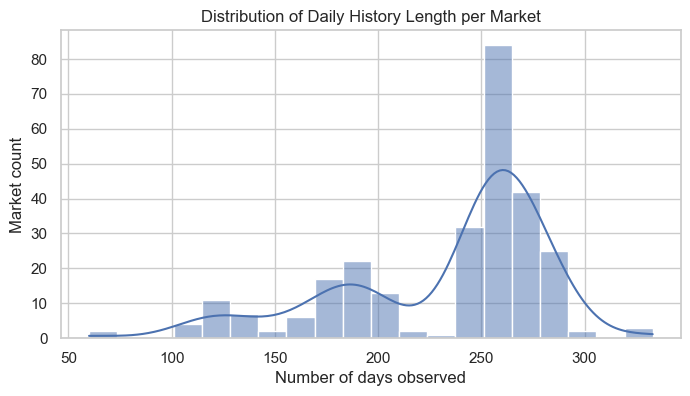

In [25]:
plt.figure(figsize=(8, 4))
sns.histplot(market_summary['n_days'], bins=20, kde=True)
plt.title('Distribution of Daily History Length per Market')
plt.xlabel('Number of days observed')
plt.ylabel('Market count')
plt.show()

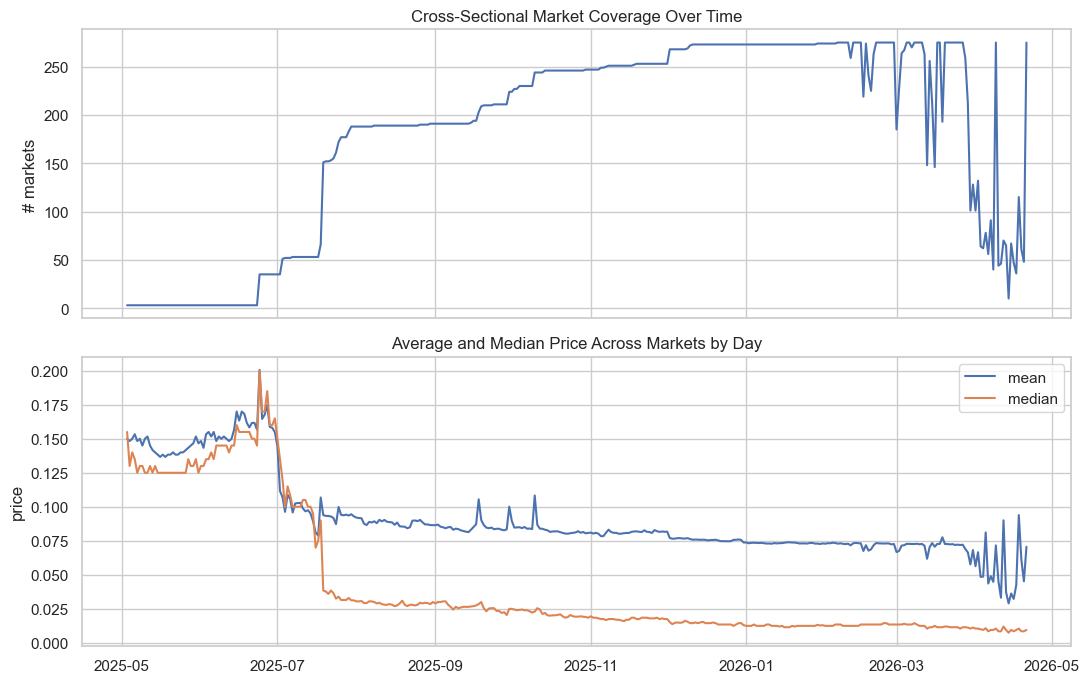

In [26]:
daily_cross_section = (
    df.groupby('date', as_index=False)
      .agg(
          n_markets=('market_id', 'nunique'),
          avg_price=('price', 'mean'),
          median_price=('price', 'median')
      )
)

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(daily_cross_section['date'], daily_cross_section['n_markets'])
ax[0].set_title('Cross-Sectional Market Coverage Over Time')
ax[0].set_ylabel('# markets')
ax[1].plot(daily_cross_section['date'], daily_cross_section['avg_price'], label='mean')
ax[1].plot(daily_cross_section['date'], daily_cross_section['median_price'], label='median')
ax[1].set_title('Average and Median Price Across Markets by Day')
ax[1].set_ylabel('price')
ax[1].legend()
plt.tight_layout()
plt.show()

In [27]:
# Daily return-style features
df['price_lag1'] = df.groupby('market_id')['price'].shift(1)
df['delta_price'] = df['price'] - df['price_lag1']
df['abs_delta_price'] = df['delta_price'].abs()
df['rolling_vol_7d'] = (
    df.groupby('market_id')['delta_price']
      .rolling(7)
      .std()
      .reset_index(level=0, drop=True)
)

df[['market_id', 'date', 'price', 'delta_price', 'rolling_vol_7d']].head(12)

,market_id,date,price,delta_price,rolling_vol_7d
0,540819,2025-05-03,0.115,NaN,NaN
1,540819,2025-05-04,0.120,0.005,NaN
2,540819,2025-05-05,0.120,0.000,NaN
3,540819,2025-05-06,0.125,0.005,NaN
4,540819,2025-05-07,0.115,-0.010,NaN
5,540819,2025-05-08,0.115,0.000,NaN
6,540819,2025-05-09,0.115,0.000,NaN
7,540819,2025-05-10,0.120,0.005,0.005345
8,540819,2025-05-11,0.125,0.005,0.005345
9,540819,2025-05-12,0.130,0.005,0.005563


In [28]:
top_volatile_markets = (
    df.groupby('market_id', as_index=False)
      .agg(
          question=('question', 'first'),
          mean_abs_move=('abs_delta_price', 'mean'),
          p95_abs_move=('abs_delta_price', lambda x: x.quantile(0.95)),
          mean_rolling_vol_7d=('rolling_vol_7d', 'mean')
      )
      .sort_values('mean_abs_move', ascending=False)
)

top_volatile_markets.head(10)

,market_id,question,mean_abs_move,p95_abs_move,mean_rolling_vol_7d
274,628954,Will Eric Swalwell win the California Governor...,0.025091,0.08100,0.037560
237,599324,Will Janet Mills be the Democratic nominee for...,0.025051,0.10100,0.033363
236,599323,Will Graham Platner be the Democratic nominee ...,0.023510,0.09075,0.030341
262,628940,Will Steve Hilton win the California Governor ...,0.015723,0.06055,0.020934
260,628936,Will Rick Caruso win the California Governor E...,0.015436,0.06025,0.019902
192,564161,Will Nikola Jokic win the 2025–2026 NBA MVP?,0.015384,0.05000,0.023406
238,601818,Will Tarcisio de Freitas win the 2026 Brazilia...,0.015132,0.05700,0.019675
199,564210,Will the Oklahoma City Thunder win the NBA Wes...,0.014466,0.05000,0.021591
213,566187,Will Arsenal win the 2025–26 English Premier L...,0.014458,0.07000,0.021632
224,567687,Russia x Ukraine ceasefire by end of 2026?,0.013466,0.04075,0.017593


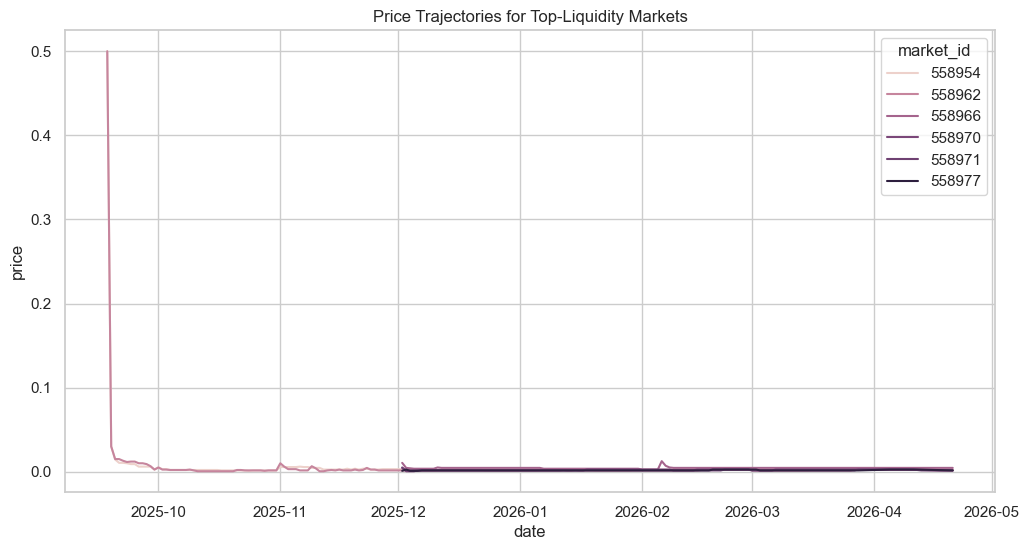

In [29]:
# Plot trajectories for highest-liquidity markets
top_liq_ids = market_summary.nlargest(6, 'liquidity')['market_id'].tolist()
plot_df = df[df['market_id'].isin(top_liq_ids)].copy()

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='date', y='price', hue='market_id', legend='full')
plt.title('Price Trajectories for Top-Liquidity Markets')
plt.xlabel('date')
plt.ylabel('price')
plt.show()

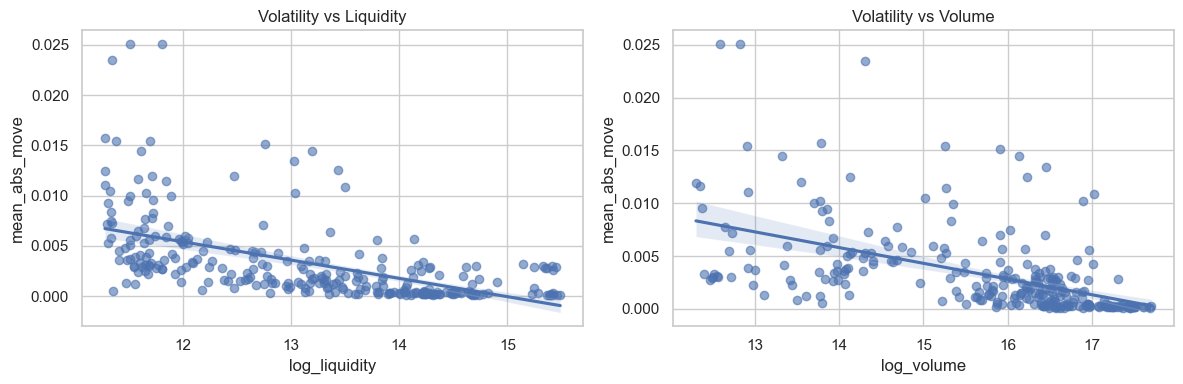

In [30]:
# Cross-sectional relationship: liquidity and volatility
liq_vol_df = (
    df.groupby('market_id', as_index=False)
      .agg(
          liquidity=('liquidity', 'last'),
          volume=('volume', 'last'),
          mean_abs_move=('abs_delta_price', 'mean')
      )
)
liq_vol_df['log_liquidity'] = np.log1p(liq_vol_df['liquidity'])
liq_vol_df['log_volume'] = np.log1p(liq_vol_df['volume'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=liq_vol_df, x='log_liquidity', y='mean_abs_move', scatter_kws={'alpha': 0.6}, ax=ax[0])
ax[0].set_title('Volatility vs Liquidity')
sns.regplot(data=liq_vol_df, x='log_volume', y='mean_abs_move', scatter_kws={'alpha': 0.6}, ax=ax[1])
ax[1].set_title('Volatility vs Volume')
plt.tight_layout()
plt.show()

## Updated Architecture Prompt (for next build)

Use this prompt for the next LLM-assisted architecture update:

> We now have a panel dataset (`polymarket_daily_panel_60plus.csv`) with one row per market-day and at least 60 daily observations per market. Please redesign our current Polymarket mispricing architecture from snapshot-only modeling to panel-aware time-series modeling.
>
> ### Current constraints and assets
> - Existing pipeline includes loaders, feature engineering, execution pricing, baseline ridge model, constrained optimizer, and walk-forward logic.
> - Data fields include `market_id`, `question`, `date`, `price`, `volume`, `liquidity`, `active`, `closed`, `end_date_iso`, and token metadata.
> - We still mostly observe open markets, so true terminal resolution labels are sparse without external enrichment.
>
> ### Requested architecture update
> 1. Propose a modular panel-time-series architecture (data ingestion, panel feature store, forecasting layer, portfolio/position sizing layer, evaluation layer).
> 2. Specify leakage-safe validation strategy (rolling/expanding windows by date, grouped by market, with cross-sectional integrity checks).
> 3. Define feature sets:
>    - market-level lag features (`t-1`, `t-7`, rolling volatility, momentum, mean reversion signals)
>    - cross-sectional features (relative mispricing vs peers, percentile ranks by category/liquidity buckets)
>    - microstructure proxies from volume/liquidity.
> 4. Recommend model stack progression (baseline linear/logit, panel regularized models, tree-based models, then sequence models only if justified).
> 5. Update optimizer inputs/constraints to use forecast distributions and turnover/liquidity penalties in a daily rebalance loop.
> 6. Define monitoring and diagnostics: drift, calibration, factor exposure, regime sensitivity, and PnL decomposition.
>
> ### Key research questions to prioritize
> - Which markets exhibit persistent return predictability after transaction-cost-aware assumptions?
> - Does liquidity dampen or amplify short-horizon forecastability?
> - Are there stable cross-sectional factors (event type/category, maturity horizon, crowding) that improve edge estimates?
> - How should we model unresolved/open-market risk when terminal outcomes are unavailable?
> - Which validation design best reflects production deployment (daily rebalance over partially overlapping market lifecycles)?
>
> Return: an implementation-ready blueprint with folder structure changes, interface contracts, and a staged migration plan from the current codebase.